### Importación de datos



In [42]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\gomez\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [43]:

import pandas as pd # type: ignore

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [44]:
tienda['Total'] = tienda['Precio'] 
tienda2['Total'] = tienda2['Precio'] 
tienda3['Total'] = tienda3['Precio'] 
tienda4['Total'] = tienda4['Precio'] 
#suma_ingresos = tienda['Ingresos'].sum()
print(f"La suma de los ingresos de la tienda 1 es: {tienda['Total'].sum()}")
print(f"La suma de los ingresos de la tienda 2 es: {tienda2['Total'].sum()}")
print(f"La suma de los ingresos de la tienda 3 es: {tienda3['Total'].sum()}")
print(f"La suma de los ingresos de la tienda 4 es: {tienda4['Total'].sum()}")

suma_total = (
    tienda['Total'].sum() +
    tienda2['Total'].sum() +
    tienda3['Total'].sum() +
    tienda4['Total'].sum()
)

print(f"La suma total de ingresos de todas las tiendas es: {suma_total}")


La suma de los ingresos de la tienda 1 es: 1150880400.0
La suma de los ingresos de la tienda 2 es: 1116343500.0
La suma de los ingresos de la tienda 3 es: 1098019600.0
La suma de los ingresos de la tienda 4 es: 1038375700.0
La suma total de ingresos de todas las tiendas es: 4403619200.0


# 2. Ventas por categoría

In [45]:
# Agregar una columna 'Tienda' a cada DataFrame
tienda['Tienda'] = 'Tienda 1'
tienda2['Tienda'] = 'Tienda 2'
tienda3['Tienda'] = 'Tienda 3'
tienda4['Tienda'] = 'Tienda 4'

# Combinar todos los DataFrames en uno solo
df_combinado = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

# Contar la cantidad de productos vendidos por tienda y categoría
ventas_por_tienda_categoria = (
    df_combinado.groupby(['Tienda', 'Categoría del Producto'])
    .size()
    .reset_index(name='Cantidad Vendida')
)
print('La cantidad de productos vendidos por tienda y categoría es:')
print(ventas_por_tienda_categoria)

# Encontrar la categoría más popular para cada tienda
categorias_populares = (
    ventas_por_tienda_categoria
    .loc[ventas_por_tienda_categoria.groupby('Tienda')['Cantidad Vendida'].idxmax()]
    .reset_index(drop=True)
)
print('\nLas categorías más populares por tienda son:')
print(categorias_populares)

La cantidad de productos vendidos por tienda y categoría es:
      Tienda   Categoría del Producto  Cantidad Vendida
0   Tienda 1  Artículos para el hogar               171
1   Tienda 1     Deportes y diversión               284
2   Tienda 1        Electrodomésticos               312
3   Tienda 1             Electrónicos               448
4   Tienda 1   Instrumentos musicales               182
5   Tienda 1                 Juguetes               324
6   Tienda 1                   Libros               173
7   Tienda 1                  Muebles               465
8   Tienda 2  Artículos para el hogar               181
9   Tienda 2     Deportes y diversión               275
10  Tienda 2        Electrodomésticos               305
11  Tienda 2             Electrónicos               422
12  Tienda 2   Instrumentos musicales               224
13  Tienda 2                 Juguetes               313
14  Tienda 2                   Libros               197
15  Tienda 2                  Muebles      

# 3. Calificación promedio de la tienda


In [46]:
# Combinar todos los DataFrames en uno solo
df_combinado = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

# Calcular el promedio de calificaciones por tienda
promedio_por_tienda = df_combinado.groupby('Tienda')['Calificación'].mean().reset_index(name='Calificación Promedio')

# Ordenar las tiendas por satisfacción del cliente
promedio_por_tienda_ordenado = promedio_por_tienda.sort_values(by='Calificación Promedio', ascending=False)

# Mostrar los resultados
print('El promedio de calificaciones por tienda es:')
print(promedio_por_tienda)

print('\nLas tiendas ordenadas por satisfacción del cliente son:')
print(promedio_por_tienda_ordenado)

El promedio de calificaciones por tienda es:
     Tienda  Calificación Promedio
0  Tienda 1               3.976685
1  Tienda 2               4.037304
2  Tienda 3               4.048326
3  Tienda 4               3.995759

Las tiendas ordenadas por satisfacción del cliente son:
     Tienda  Calificación Promedio
2  Tienda 3               4.048326
1  Tienda 2               4.037304
3  Tienda 4               3.995759
0  Tienda 1               3.976685


# 4. Productos más y menos vendidos

In [47]:
# Contar las ventas por producto para cada tienda
ventas_por_producto_tienda1 = tienda['Producto'].value_counts().reset_index()
ventas_por_producto_tienda1.columns = ['Producto', 'Total Ventas']

ventas_por_producto_tienda2 = tienda2['Producto'].value_counts().reset_index()
ventas_por_producto_tienda2.columns = ['Producto', 'Total Ventas']

ventas_por_producto_tienda3 = tienda3['Producto'].value_counts().reset_index()
ventas_por_producto_tienda3.columns = ['Producto', 'Total Ventas']

ventas_por_producto_tienda4 = tienda4['Producto'].value_counts().reset_index()
ventas_por_producto_tienda4.columns = ['Producto', 'Total Ventas']

# Mostrar los resultados
print('Ventas por producto en la Tienda 1:')
print(ventas_por_producto_tienda1)

print('Ventas por producto en la Tienda 2:')
print(ventas_por_producto_tienda2)

print('Ventas por producto en la Tienda 3:')
print(ventas_por_producto_tienda3)

print('Ventas por producto en la Tienda 4:')
print(ventas_por_producto_tienda4)

Ventas por producto en la Tienda 1:
                       Producto  Total Ventas
0                    Microondas            60
1                 TV LED UHD 4K            60
2                       Armario            60
3              Secadora de ropa            58
4                 Mesa de noche            56
5       Bloques de construcción            56
6           Balón de baloncesto            55
7                     Bicicleta            54
8                  Vaso térmico            54
9                  Refrigerador            54
10                    Impresora            54
11                      Batería            53
12                   Cubertería            52
13    Carrito de control remoto            52
14          Modelado predictivo            51
15                  Auriculares            50
16            Ajedrez de madera            49
17                    Iphone 15            49
18                 Lavavajillas            48
19             Lavadora de ropa            4

In [48]:


# Función para encontrar productos más y menos vendidos
def encontrar_productos_mas_y_menos_vendidos(df):
    max_ventas = df['Total Ventas'].max()
    min_ventas = df['Total Ventas'].min()
    
    productos_mas_vendidos = df[df['Total Ventas'] == max_ventas]
    productos_menos_vendidos = df[df['Total Ventas'] == min_ventas]
    
    return productos_mas_vendidos, productos_menos_vendidos

# Contar las ventas por producto para cada tienda
ventas_por_producto_tienda1 = tienda['Producto'].value_counts().reset_index()
ventas_por_producto_tienda1.columns = ['Producto', 'Total Ventas']

ventas_por_producto_tienda2 = tienda2['Producto'].value_counts().reset_index()
ventas_por_producto_tienda2.columns = ['Producto', 'Total Ventas']

ventas_por_producto_tienda3 = tienda3['Producto'].value_counts().reset_index()
ventas_por_producto_tienda3.columns = ['Producto', 'Total Ventas']

ventas_por_producto_tienda4 = tienda4['Producto'].value_counts().reset_index()
ventas_por_producto_tienda4.columns = ['Producto', 'Total Ventas']

# Encontrar productos más y menos vendidos para cada tienda
mas_vendidos_tienda1, menos_vendidos_tienda1 = encontrar_productos_mas_y_menos_vendidos(ventas_por_producto_tienda1)
mas_vendidos_tienda2, menos_vendidos_tienda2 = encontrar_productos_mas_y_menos_vendidos(ventas_por_producto_tienda2)
mas_vendidos_tienda3, menos_vendidos_tienda3 = encontrar_productos_mas_y_menos_vendidos(ventas_por_producto_tienda3)
mas_vendidos_tienda4, menos_vendidos_tienda4 = encontrar_productos_mas_y_menos_vendidos(ventas_por_producto_tienda4)
# Mostrar resultados
print("Productos más vendidos en Tienda 1:")
print(mas_vendidos_tienda1)

print("Productos menos vendidos en Tienda 1:")
print(menos_vendidos_tienda1)

print("Productos más vendidos en Tienda 2:")
print(mas_vendidos_tienda2)

print("Productos menos vendidos en Tienda 2:")
print(menos_vendidos_tienda2)

print("Productos más vendidos en Tienda 3:")
print(mas_vendidos_tienda3)

print("Productos menos vendidos en Tienda 3:")
print(menos_vendidos_tienda3)


print("Productos más vendidos en Tienda 4:")
print(mas_vendidos_tienda4)

print("Productos menos vendidos en Tienda 4:")
print(menos_vendidos_tienda4)

Productos más vendidos en Tienda 1:
        Producto  Total Ventas
0     Microondas            60
1  TV LED UHD 4K            60
2        Armario            60
Productos menos vendidos en Tienda 1:
                     Producto  Total Ventas
49  Auriculares con micrófono            33
50               Celular ABXY            33
Productos más vendidos en Tienda 2:
                    Producto  Total Ventas
0  Iniciando en programación            65
Productos menos vendidos en Tienda 2:
         Producto  Total Ventas
50  Juego de mesa            32
Productos más vendidos en Tienda 3:
        Producto  Total Ventas
0  Kit de bancas            57
Productos menos vendidos en Tienda 3:
                   Producto  Total Ventas
50  Bloques de construcción            35
Productos más vendidos en Tienda 4:
   Producto  Total Ventas
0  Cama box            62
Productos menos vendidos en Tienda 4:
              Producto  Total Ventas
50  Guitarra eléctrica            33


# 5. Envío promedio por tienda

In [49]:
# Combinar todos los DataFrames en uno solo
df_combinado = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

# Calcular el costo de envío promedio por tienda
costo_envio_promedio_por_tienda = round(df_combinado.groupby('Tienda')['Costo de envío'].mean().reset_index(name='Costo de Envío Promedio'),2)

# Mostrar los resultados
print('El costo de envío promedio por tienda es:')
print(costo_envio_promedio_por_tienda)

El costo de envío promedio por tienda es:
     Tienda  Costo de Envío Promedio
0  Tienda 1                 26018.61
1  Tienda 2                 25216.24
2  Tienda 3                 24805.68
3  Tienda 4                 23459.46


In [50]:
# Ordenar las tiendas por costo de envío promedio
costo_envio_ordenado = round(costo_envio_promedio_por_tienda.sort_values(by='Costo de Envío Promedio', ascending=True),2)
print('Las tiendas ordenadas por costo de envío promedio son:')
print(costo_envio_ordenado)

Las tiendas ordenadas por costo de envío promedio son:
     Tienda  Costo de Envío Promedio
3  Tienda 4                 23459.46
2  Tienda 3                 24805.68
1  Tienda 2                 25216.24
0  Tienda 1                 26018.61


# 6. Representamos gráficamente el análisis de los datos

In [ ]:
%pip install matplotlib
import matplotlib.pyplot as plt  # type: ignore

### Ingresos totales por cada tienda

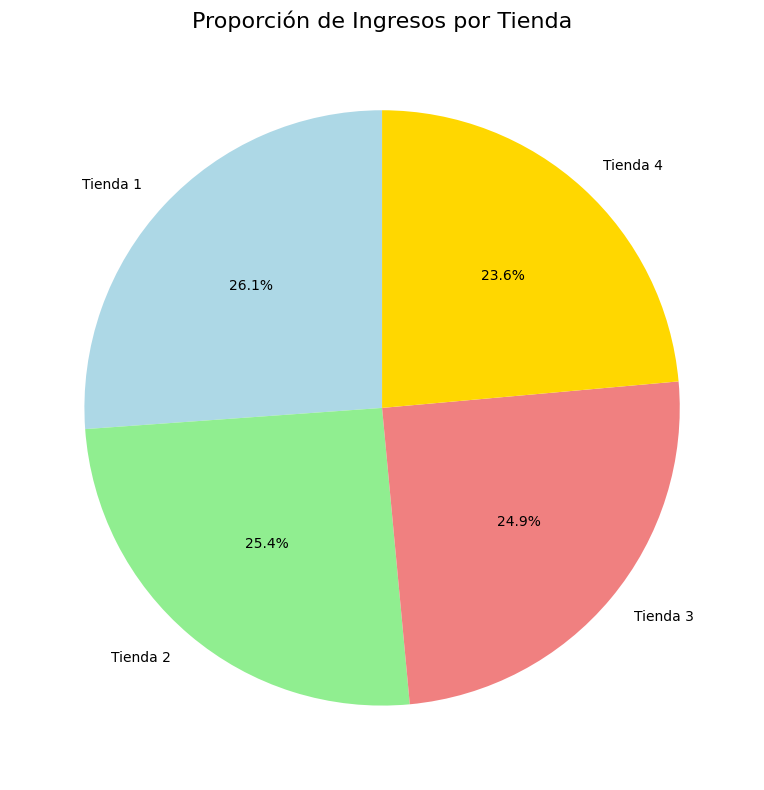

In [52]:
# Calcular los ingresos totales para cada tienda
ingresos_tienda1 = tienda['Total'].sum()
ingresos_tienda2 = tienda2['Total'].sum()
ingresos_tienda3 = tienda3['Total'].sum()
ingresos_tienda4 = tienda4['Total'].sum()

# Crear un DataFrame con los resultados
data = {
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4', 'Total'],
    'Ingresos Totales': [ingresos_tienda1, ingresos_tienda2, ingresos_tienda3, ingresos_tienda4, suma_total]
}
df_ingresos = pd.DataFrame(data)

# Crear un gráfico de pastel
plt.figure(figsize=(8, 8))
plt.pie(
    df_ingresos['Ingresos Totales'][:-1],  # Excluir la última fila ('Total')
    labels=df_ingresos['Tienda'][:-1],  # Excluir la última fila ('Total')
    autopct='%1.1f%%',  # Mostrar porcentajes
    startangle=90,
    colors=['lightblue', 'lightgreen', 'lightcoral', 'gold']
)
plt.title('Proporción de Ingresos por Tienda', fontsize=16)
plt.tight_layout()
plt.show()

### Productos vendidos por tienda y por categoría

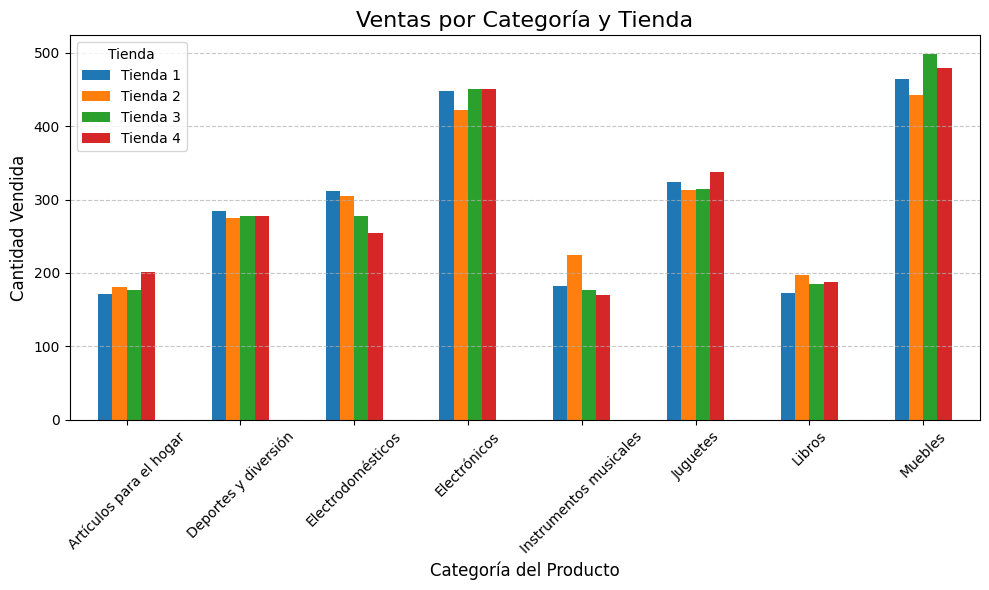

In [53]:

# Crear una tabla pivot para organizar los datos
tabla_pivot = ventas_por_tienda_categoria.pivot(
    index='Categoría del Producto',  # Eje X: Categorías
    columns='Tienda',               # Separar por tienda
    values='Cantidad Vendida'       # Valores: Cantidad vendida
).fillna(0)  # Rellenar valores faltantes con 0

# Crear el gráfico de barras
tabla_pivot.plot(kind='bar', figsize=(10, 6), rot=45)

# Personalizar el gráfico
plt.title('Ventas por Categoría y Tienda', fontsize=16)
plt.xlabel('Categoría del Producto', fontsize=12)
plt.ylabel('Cantidad Vendida', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Tienda')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

###  Calificación promedio de la tienda

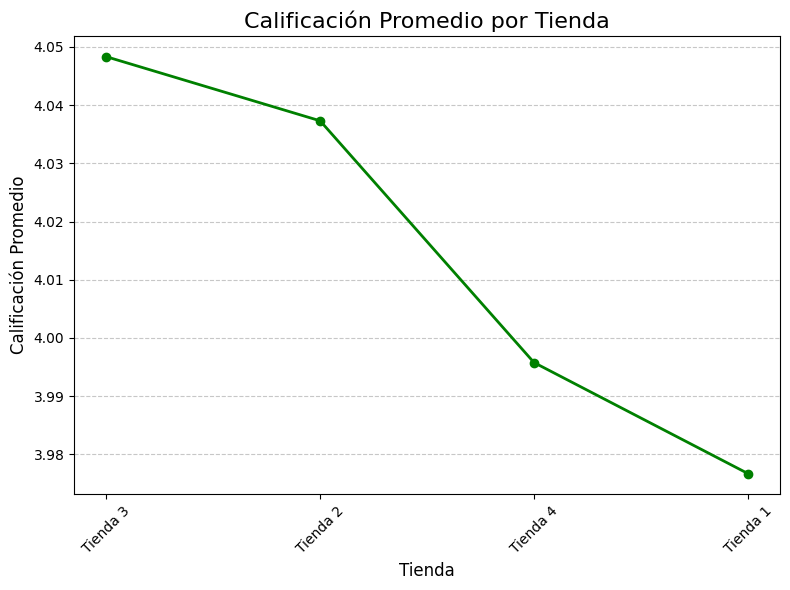

In [54]:
# Crear un gráfico de líneas
plt.figure(figsize=(8, 6))
plt.plot(
    promedio_por_tienda_ordenado['Tienda'],
    promedio_por_tienda_ordenado['Calificación Promedio'],
    marker='o',
    color='green',
    linestyle='-',
    linewidth=2
)

# Personalizar el gráfico
plt.title('Calificación Promedio por Tienda', fontsize=16)
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Calificación Promedio', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

### Productos más y menos vendidos

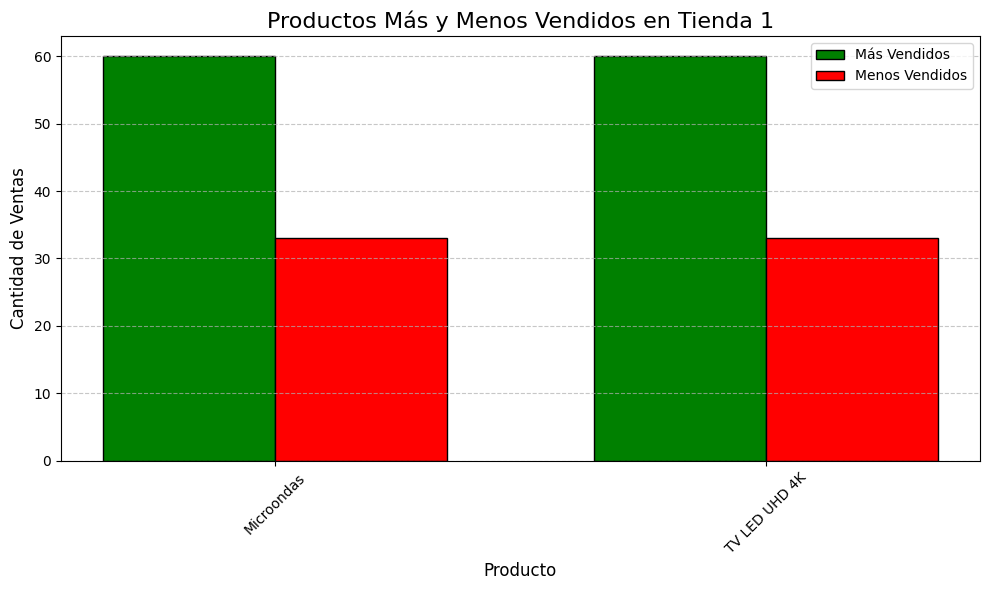

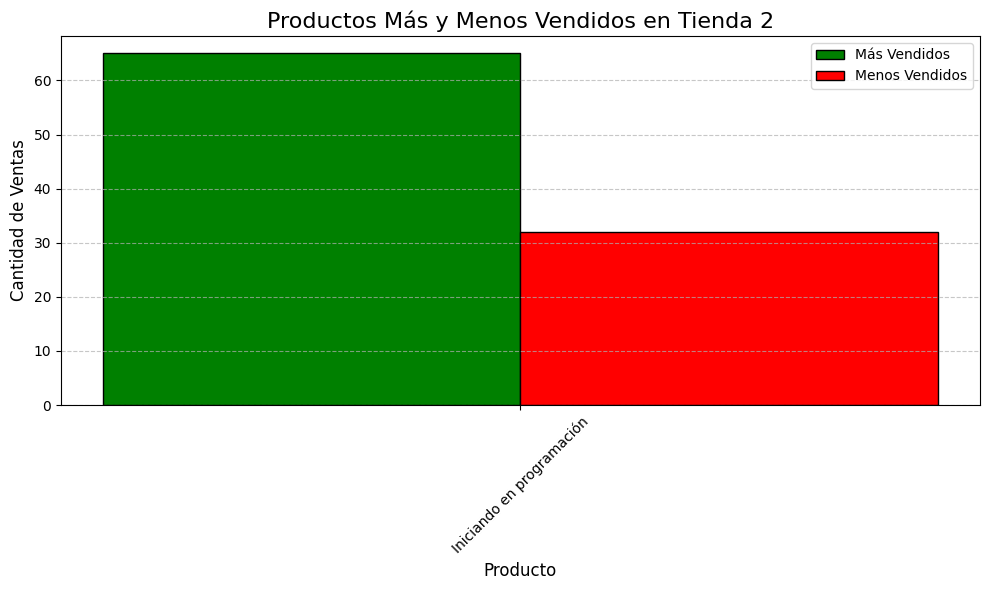

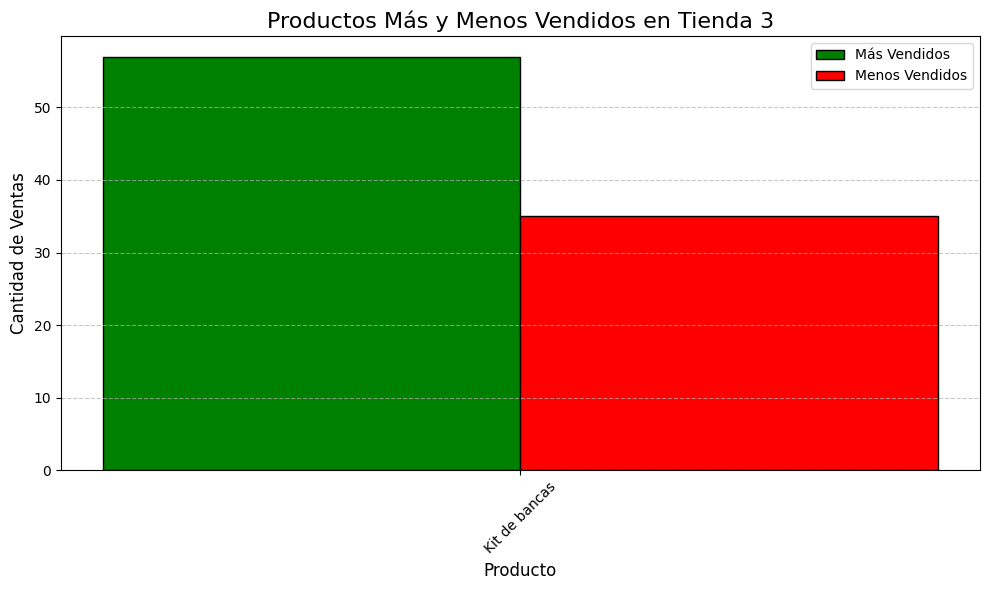

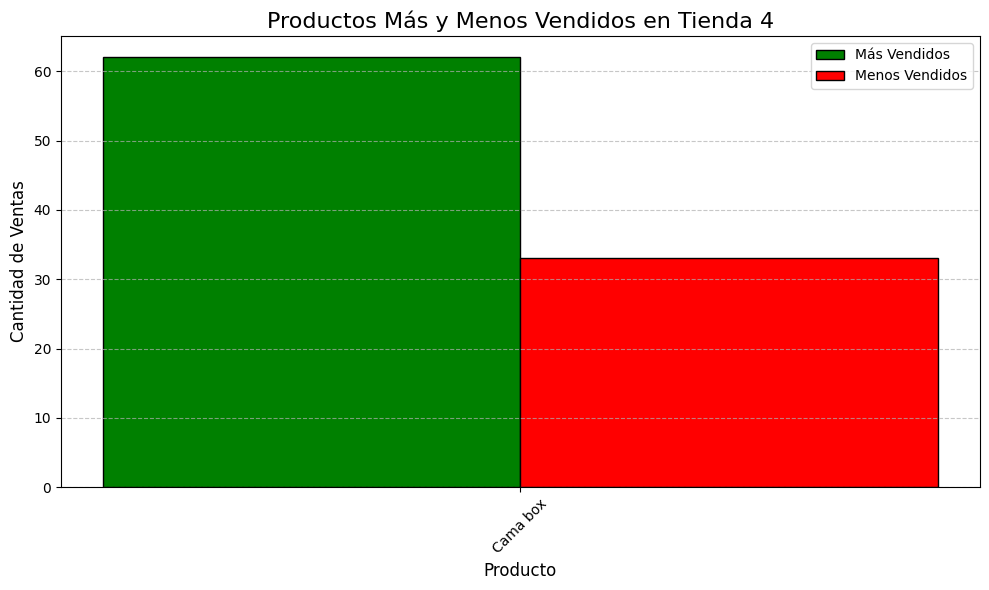

In [58]:
def graficar_productos_mas_y_menos_vendidos_vertical(mas_vendidos, menos_vendidos, tienda_nombre):
    # Ensure both DataFrames have the same length
    min_length = min(len(mas_vendidos), len(menos_vendidos))
    mas_vendidos = mas_vendidos.head(min_length)
    menos_vendidos = menos_vendidos.head(min_length)

    fig, ax = plt.subplots(figsize=(10, 6))
    bar_width = 0.35
    indices = range(len(mas_vendidos))
    ax.bar(indices, mas_vendidos['Total Ventas'], width=bar_width, color='green', edgecolor='black', label='Más Vendidos')
    ax.bar([i + bar_width for i in indices], menos_vendidos['Total Ventas'], width=bar_width, color='red', edgecolor='black', label='Menos Vendidos')
    ax.set_title(f'Productos Más y Menos Vendidos en {tienda_nombre}', fontsize=16)
    ax.set_xlabel('Producto', fontsize=12)
    ax.set_ylabel('Cantidad de Ventas', fontsize=12)
    ax.set_xticks([i + bar_width / 2 for i in indices])
    ax.set_xticklabels(mas_vendidos['Producto'], rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Graficar para cada tienda
graficar_productos_mas_y_menos_vendidos_vertical(mas_vendidos_tienda1, menos_vendidos_tienda1, 'Tienda 1')
graficar_productos_mas_y_menos_vendidos_vertical(mas_vendidos_tienda2, menos_vendidos_tienda2, 'Tienda 2')
graficar_productos_mas_y_menos_vendidos_vertical(mas_vendidos_tienda3, menos_vendidos_tienda3, 'Tienda 3')
graficar_productos_mas_y_menos_vendidos_vertical(mas_vendidos_tienda4, menos_vendidos_tienda4, 'Tienda 4')

### 

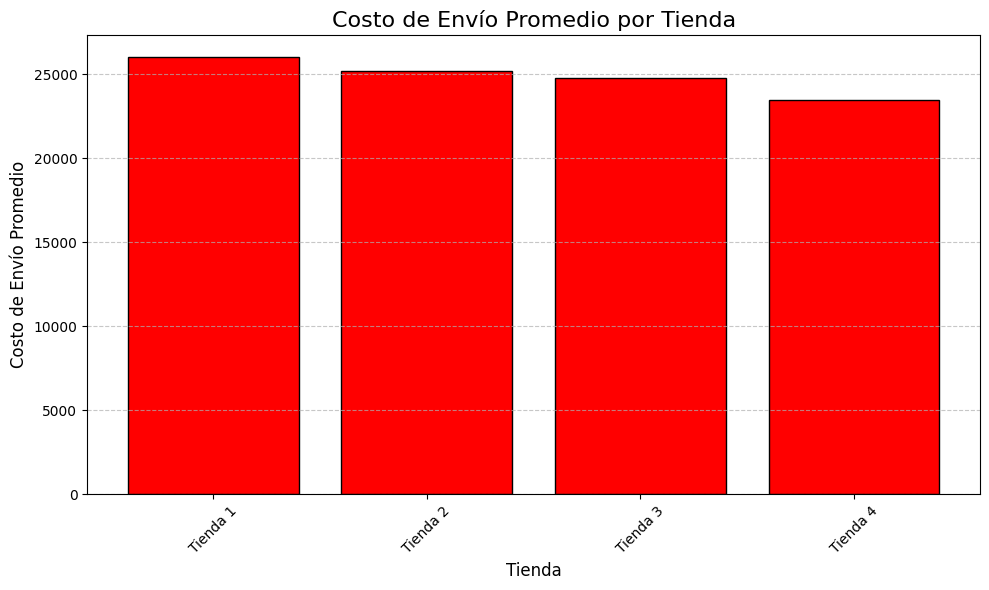

In [60]:
# Crear el gráfico de barras verticales
plt.figure(figsize=(10, 6))
plt.bar(
    costo_envio_promedio_por_tienda['Tienda'],
    costo_envio_promedio_por_tienda['Costo de Envío Promedio'],
    color='red',
    edgecolor='black'
)

# Personalizar el gráfico
plt.title('Costo de Envío Promedio por Tienda', fontsize=16)
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Costo de Envío Promedio', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()
plt.show()